In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
csv_file="/content/drive/MyDrive/data/train/annotations.csv"

In [9]:
import pandas as pd
df = pd.read_csv(csv_file)
df.head(5)

,filename,width,height,class,xmin,ymin,xmax,ymax
0,srinagar-indian-administered-kashmir19th-april...,640,640,2,30,69,169,522
1,srinagar-indian-administered-kashmir19th-april...,640,640,2,480,99,579,481
2,srinagar-indian-administered-kashmir19th-april...,640,640,2,227,95,342,481
3,srinagar-indian-administered-kashmir19th-april...,640,640,2,428,102,489,441
4,srinagar-indian-administered-kashmir19th-april...,640,640,2,345,82,445,491


In [10]:
class_counts = df['class'].value_counts()

# Print the results
print(class_counts)

class
1    290
2    250
0    241
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
data_csv_path = "/content/drive/MyDrive/uniform.v1i.tensorflow/_annotations.csv"
images_dir = "/content/drive/MyDrive/uniform.v1i.tensorflow/images"

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 3

# Load CSV
df = pd.read_csv(data_csv_path)
df['class'] = df['class'].astype('category').cat.codes

In [ ]:
# Convert class column to categorical and numeric codes
df['class'] = df['class'].astype('category')
class_mapping = dict(enumerate(df['class'].cat.categories))
print(class_mapping)


{0: 0, 1: 1, 2: 2}


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['class'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['class'])


In [ ]:
len(test_df)

98

In [ ]:
def data_generator(df, images_dir, batch_size, image_size, augment=False):
    while True:
        batch = df.sample(batch_size)
        images = []
        bboxes = []
        labels = []

        for _, row in batch.iterrows():
            image_path = os.path.join(images_dir, row['filename'])
            image = cv2.imread(image_path)
            image = cv2.resize(image, (image_size, image_size))
            images.append(image)

            bbox = [
                row['xmin'] / row['width'],
                row['ymin'] / row['height'],
                row['xmax'] / row['width'],
                row['ymax'] / row['height']
            ]
            bboxes.append(bbox)
            labels.append(row['class'])

        yield (
            tf.convert_to_tensor(np.array(images) / 255.0, dtype=tf.float32),
            {
                'bbox': tf.convert_to_tensor(np.array(bboxes), dtype=tf.float32),
                'class': tf.convert_to_tensor(np.array(labels), dtype=tf.int32)
            }
        )


In [ ]:
def create_tf_dataset(df, images_dir, batch_size, image_size):
    output_signature = (
        tf.TensorSpec(shape=(None, image_size, image_size, 3), dtype=tf.float32),
        {
            'bbox': tf.TensorSpec(shape=(None, 4), dtype=tf.float32),
            'class': tf.TensorSpec(shape=(None,), dtype=tf.int32)
        }
    )
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(df, images_dir, batch_size, image_size),
        output_signature=output_signature
    )
    return dataset

train_dataset = create_tf_dataset(train_df, images_dir, BATCH_SIZE, IMAGE_SIZE)
val_dataset = create_tf_dataset(val_df, images_dir, BATCH_SIZE, IMAGE_SIZE)


In [ ]:
base_model = tf.keras.applications.EfficientNetB0(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False)
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
bbox_head = tf.keras.layers.Dense(4, activation='sigmoid', name='bbox')(x)
class_head = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='class')(x)

model = tf.keras.Model(inputs, [bbox_head, class_head])
model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss={'bbox': 'mse', 'class': 'sparse_categorical_crossentropy'},
    metrics={'bbox': 'mae', 'class': 'accuracy'}
)

In [ ]:
model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=len(train_df) // BATCH_SIZE,
    validation_steps=len(val_df) // BATCH_SIZE,
    epochs=EPOCHS
)


Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - bbox_loss: 0.0966 - bbox_mae: 0.2760 - class_accuracy: 0.3414 - class_loss: 1.1024 - loss: 1.1990 - val_bbox_loss: 0.0579 - val_bbox_mae: 0.2073 - val_class_accuracy: 0.3333 - val_class_loss: 1.0992 - val_loss: 1.1572
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - bbox_loss: 0.0499 - bbox_mae: 0.1865 - class_accuracy: 0.3755 - class_loss: 1.0978 - loss: 1.1477 - val_bbox_loss: 0.0474 - val_bbox_mae: 0.1794 - val_class_accuracy: 0.3333 - val_class_loss: 1.1035 - val_loss: 1.1509
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - bbox_loss: 0.0427 - bbox_mae: 0.1664 - class_accuracy: 0.3553 - class_loss: 1.0997 - loss: 1.1424 - val_bbox_loss: 0.0493 - val_bbox_mae: 0.1790 - val_class_accuracy: 0.3958 - val_class_loss: 1.0923 - val_loss: 1.1416
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - bbox_loss: 0.0444 - bbox_mae: 0.1687 - class_accuracy: 0.3909 - class_loss: 1.0917 - loss: 1.1360 - val_bbox_loss: 0.0489 - val_bbox_mae: 

In [ ]:
# Test Inference
def infer(image_path, model, image_size):
    image = cv2.imread(image_path)
    original_shape = image.shape[:2]
    resized_image = cv2.resize(image, (image_size, image_size)) / 255.0
    predictions = model.predict(np.expand_dims(resized_image, axis=0))
    bbox, class_prob = predictions
    class_id = np.argmax(class_prob)
    bbox = bbox[0] * [original_shape[1], original_shape[0], original_shape[1], original_shape[0]]
    return bbox, class_id

test_image_path = os.path.join(images_dir, test_df.iloc[20]['filename'])
bbox, class_id = infer(test_image_path, model, IMAGE_SIZE)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


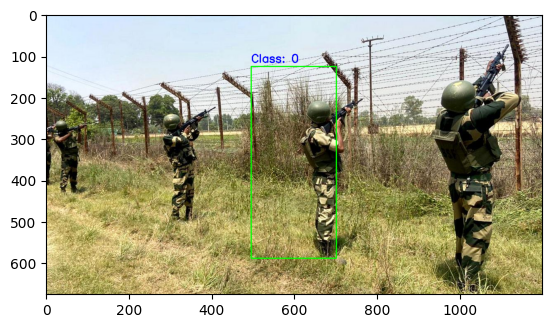

In [ ]:
image = cv2.imread(test_image_path)
cv2.rectangle(image, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
cv2.putText(image, f"Class: {class_id}", (int(bbox[0]), int(bbox[1]-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

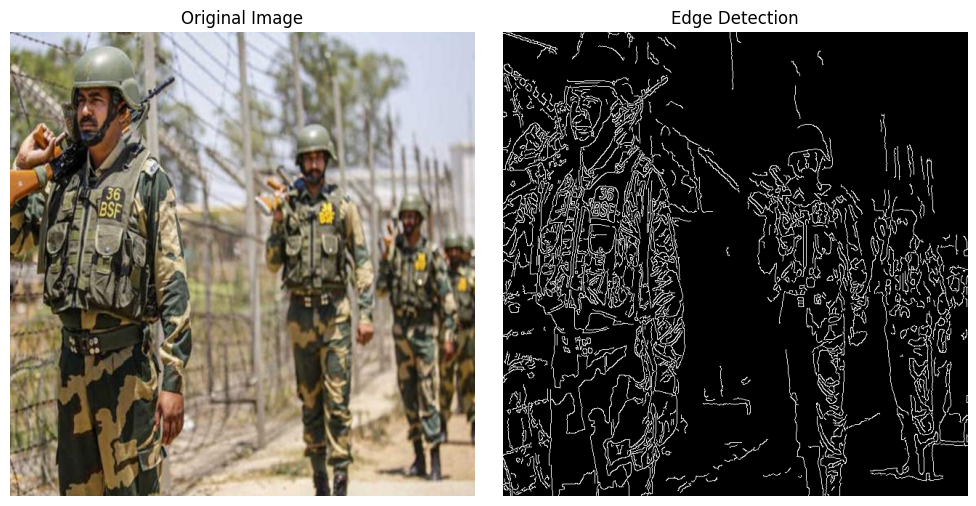

In [16]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/drive/MyDrive/Unform_detection.v13i.yolov8/jpg_94_jpg.rf.9f648754fa256d64c4d41e07fc6a5ae4.jpg'
img = cv2.imread(image_path)

# Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Perform Canny Edge Detection
edges = cv2.Canny(gray_img, threshold1=100, threshold2=200)

# Display the original image and the edges side by side
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Edge-detected Image
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()
